Saving Q2_Ecommerce_Returns_Dataset.csv to Q2_Ecommerce_Returns_Dataset.csv
Preview:
  OrderID CustomerRegion ProductCategory  OrderValue  DeliveryDays  \
0   O5001           East         Fashion      215.44           6.0   
1   O5002          North         Fashion      269.86           2.0   
2   O5003           East     Electronics      267.41           7.0   
3   O5004           West            Home      103.40           2.0   
4   O5005           East          Beauty       32.82          11.0   

   DiscountPercent Returned PaymentMethod  
0               40       No        Wallet  
1               25      Yes          Card  
2               50       No          Card  
3              110      Yes           COD  
4               10       No        Wallet  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID         

/tmp/ipykernel_10074/1357482831.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_10074/1357482831.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

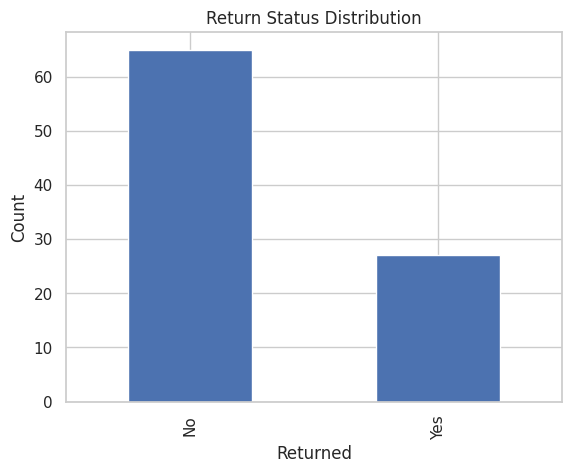

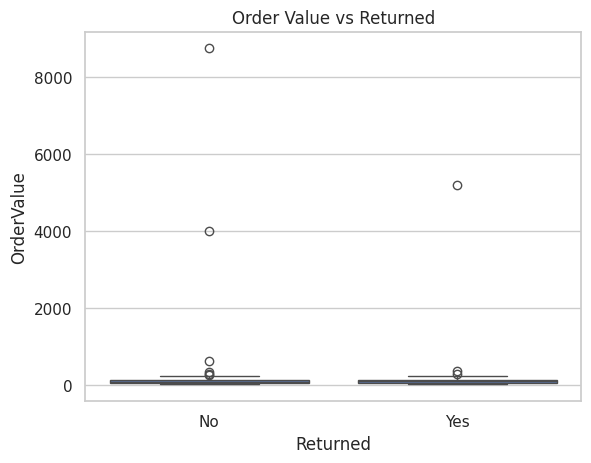

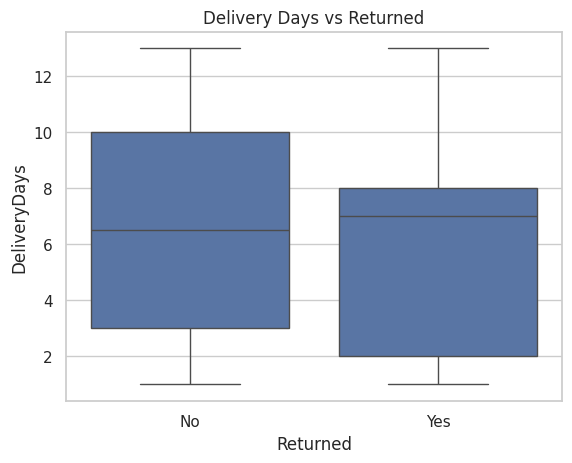

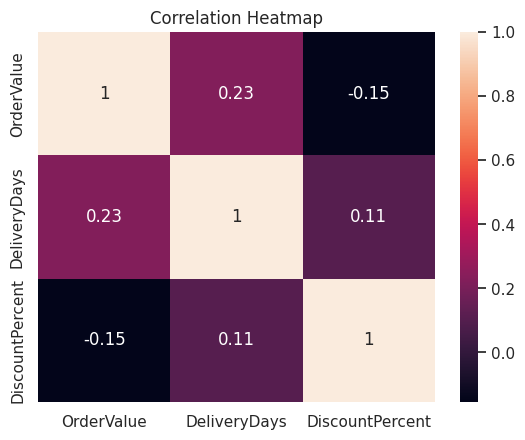


Final Data Preview:
  OrderID CustomerRegion ProductCategory  OrderValue  DeliveryDays  \
0   O5001           East         Fashion      215.44           6.0   
1   O5002          North         Fashion      269.86           2.0   
2   O5003           East     Electronics      267.41           7.0   
4   O5005           East          Beauty       32.82          11.0   
5   O5006        Central            Home      355.28           2.0   

   DiscountPercent Returned  PaymentMethod  
0               40       No         Wallet  
1               25      Yes           Card  
2               50       No           Card  
4               10       No         Wallet  
5               10      Yes  Bank transfer  


In [1]:
# E-Commerce Customer Return Behavior
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 2. UPLOAD DATASET
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print("Preview:")
print(df.head())

# 3. DATASET STRUCTURE
print("\nDataset Info:")
df.info()
print("\nSummary:")
print(df.describe(include='all'))

# DATA QUALITY SUMMARY TABLE
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values,
    "Data Type": df.dtypes.values})
print("\nData Quality Report:")
print(quality_report)

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Invalid discount (>100 or <0)
if 'DiscountPercent' in df.columns:
    print("\nInvalid Discounts:")
    print(df[(df['DiscountPercent'] < 0) | (df['DiscountPercent'] > 100)])

# Category inconsistencies
for col in ['Returned', 'PaymentMethod', 'ProductCategory', 'CustomerRegion']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())

# DATA CLEANING
# Fill missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix discount values
if 'DiscountPercent' in df.columns:
    df = df[(df['DiscountPercent'] >= 0) & (df['DiscountPercent'] <= 100)]

# Standardize categorical values
for col in ['Returned', 'PaymentMethod', 'ProductCategory', 'CustomerRegion']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()
print("\nData cleaned!")

# FREQUENCY TABLE (Returned)
freq_table = df['Returned'].value_counts()
print("\nReturned Frequency Table:")
print(freq_table)
plt.figure()
freq_table.plot(kind='bar')
plt.title("Return Status Distribution")
plt.xlabel("Returned")
plt.ylabel("Count")
plt.show()

# BOXPLOT (Order Value vs Returned)
plt.figure()
sns.boxplot(x='Returned', y='OrderValue', data=df)
plt.title("Order Value vs Returned")
plt.show()

# DELIVERY DAYS ANALYSIS
plt.figure()
sns.boxplot(x='Returned', y='DeliveryDays', data=df)
plt.title("Delivery Days vs Returned")
plt.show()

# CORRELATION HEATMAP
plt.figure()
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# FINAL CLEAN DATA
print("\nFinal Data Preview:")
print(df.head())
